## Car Price Prediction Using Machine Learning

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [28]:
df = pd.read_csv("C:/Users/Nisha/Downloads/cardekho_dataset.csv/cardekho_dataset.csv")

print("Dataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Manual    22.77    1498      98.59      5   

   selling_price  
0         120000  
1 

In [30]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [32]:
# Select Relevant Columns (As per Project)

data = df[['brand',
           'vehicle_age',
           'mileage',
           'engine',
           'fuel_type',
           'transmission_type',
           'selling_price']]


In [34]:
# Handle Missing Values
data.dropna(inplace=True)


C:\Users\Nisha\AppData\Local\Temp\ipykernel_17856\453642978.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [36]:
# Encode Categorical Variables
le = LabelEncoder()

data['brand'] = le.fit_transform(data['brand'])
data['fuel_type'] = le.fit_transform(data['fuel_type'])
data['transmission_type'] = le.fit_transform(data['transmission_type'])


C:\Users\Nisha\AppData\Local\Temp\ipykernel_17856\3236284731.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['brand'] = le.fit_transform(data['brand'])
C:\Users\Nisha\AppData\Local\Temp\ipykernel_17856\3236284731.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['fuel_type'] = le.fit_transform(data['fuel_type'])
C:\Users\Nisha\AppData\Local\Temp\ipykernel_17856\3236284731.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [38]:
# Define Features and Target
X = data[['mileage',
          'vehicle_age',
          'brand',
          'engine',
          'fuel_type',
          'transmission_type']]

y = data['selling_price']


In [40]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [42]:
# Train Models

lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [44]:
# 9. Predictions
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [46]:
# Evaluation Function

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2  :", r2_score(y_true, y_pred))

evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, dt_pred, "Decision Tree Regressor")
evaluate_model(y_test, rf_pred, "Random Forest Regressor")



Linear Regression
MAE : 317804.1902452463
RMSE: 581913.1257461312
R2  : 0.5501712578644187

Decision Tree Regressor
MAE : 105345.41667320517
RMSE: 247369.32521219872
R2  : 0.9187127214957473

Random Forest Regressor
MAE : 103605.12212667095
RMSE: 240730.8907623785
R2  : 0.923017051554808



Feature Importance:
engine               0.479817
vehicle_age          0.166839
mileage              0.166264
transmission_type    0.138046
brand                0.044588
fuel_type            0.004446
dtype: float64


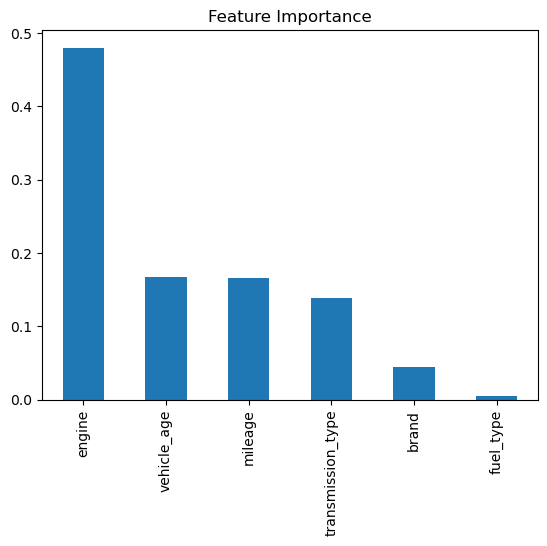

In [48]:
# Feature Importance (Random Forest)
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [50]:


# Predict Price for a New Car
# Example:
# mileage=20, age=5, brand=2, engine=1200, fuel=1, transmission=0

new_car = np.array([[20, 5, 2, 1200, 1, 0]])
predicted_price = rf.predict(new_car)

print("\nPredicted Car Price:", predicted_price[0])





Predicted Car Price: 383701.62698412704


C:\Users\Nisha\Downloads\New folder\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
